# HW07: Кластеризация и внутренние метрики качества

Домашнее задание по теме: кластеризация, внутренние метрики качества, PCA/t-SNE и "честный" unsupervised-эксперимент на синтетических данных.

## Импорты и настройки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

# Настройки
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Создание папок для артефактов
Path("artifacts/figures").mkdir(parents=True, exist_ok=True)
Path("artifacts/labels").mkdir(parents=True, exist_ok=True)

print("Импорты выполнены успешно")

Импорты выполнены успешно


## Датасет 01: Числовые признаки в разных шкалах + шумовые признаки

### 2.3.1. Загрузка данных и первичный анализ

In [2]:
df1 = pd.read_csv("data/S07-hw-dataset-01.csv")
print(f"Размер датасета: {df1.shape}")
print("\nПервые строки:")
df1.head()

Размер датасета: (12000, 9)

Первые строки:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [3]:
print("Информация о датасете:")
df1.info()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [4]:
print("Проверка пропусков:")
missing = df1.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет")
print(f"\nДоли пропусков:")
print((df1.isnull().sum() / len(df1) * 100).round(2))

Проверка пропусков:
Пропусков нет

Доли пропусков:
sample_id    0.0
f01          0.0
f02          0.0
f03          0.0
f04          0.0
f05          0.0
f06          0.0
f07          0.0
f08          0.0
dtype: float64


In [5]:
print("Базовые статистики:")
df1.describe()

Базовые статистики:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [6]:
# Разделение на признаки и идентификаторы
sample_ids_1 = df1['sample_id'].copy()
X1 = df1.drop('sample_id', axis=1)
print(f"Признаки: {list(X1.columns)}")
print(f"Размерность признаков: {X1.shape}")

Признаки: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
Размерность признаков: (12000, 8)


### 2.3.2. Препроцессинг

In [7]:
# Все признаки числовые, пропусков нет - применяем только масштабирование
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)
X1_scaled = pd.DataFrame(X1_scaled, columns=X1.columns)

print("Масштабирование выполнено")
print(f"Средние после масштабирования: {X1_scaled.mean().round(6).tolist()}")
print(f"Стандартные отклонения: {X1_scaled.std().round(6).tolist()}")

Масштабирование выполнено
Средние после масштабирования: [0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0]
Стандартные отклонения: [1.000042, 1.000042, 1.000042, 1.000042, 1.000042, 1.000042, 1.000042, 1.000042]


### 2.3.3. Модели: KMeans и DBSCAN

#### KMeans: подбор k

In [8]:
# Подбор оптимального k для KMeans
k_range = range(2, 21)
silhouette_scores_km1 = []
db_scores_km1 = []
ch_scores_km1 = []
inertias_km1 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X1_scaled)
    
    silhouette_scores_km1.append(silhouette_score(X1_scaled, labels))
    db_scores_km1.append(davies_bouldin_score(X1_scaled, labels))
    ch_scores_km1.append(calinski_harabasz_score(X1_scaled, labels))
    inertias_km1.append(kmeans.inertia_)

results_km1 = pd.DataFrame({
    'k': k_range,
    'silhouette': silhouette_scores_km1,
    'davies_bouldin': db_scores_km1,
    'calinski_harabasz': ch_scores_km1,
    'inertia': inertias_km1
})

print("Результаты подбора k для KMeans:")
print(results_km1)

Результаты подбора k для KMeans:
     k  silhouette  davies_bouldin  calinski_harabasz       inertia
0    2    0.521640        0.685330       11786.954623  48425.906977
1    3    0.396758        0.964604       10446.638111  35016.793177
2    4    0.383301        1.160349        9427.499744  28591.333390
3    5    0.354801        1.273719        8301.205994  25476.286282
4    6    0.358561        1.182256        7333.387619  23662.193601
5    7    0.324607        1.194162        6823.007844  21751.614852
6    8    0.268873        1.314180        6460.801052  20120.383853
7    9    0.253372        1.343964        6255.217145  18557.018452
8   10    0.262914        1.276985        6084.503087  17243.965830
9   11    0.265889        1.214111        5898.163564  16217.250487
10  12    0.268563        1.156264        5784.863431  15218.567028
11  13    0.274426        1.141185        5716.701640  14279.557364
12  14    0.278726        1.086926        5744.579410  13277.085581
13  15    0.288

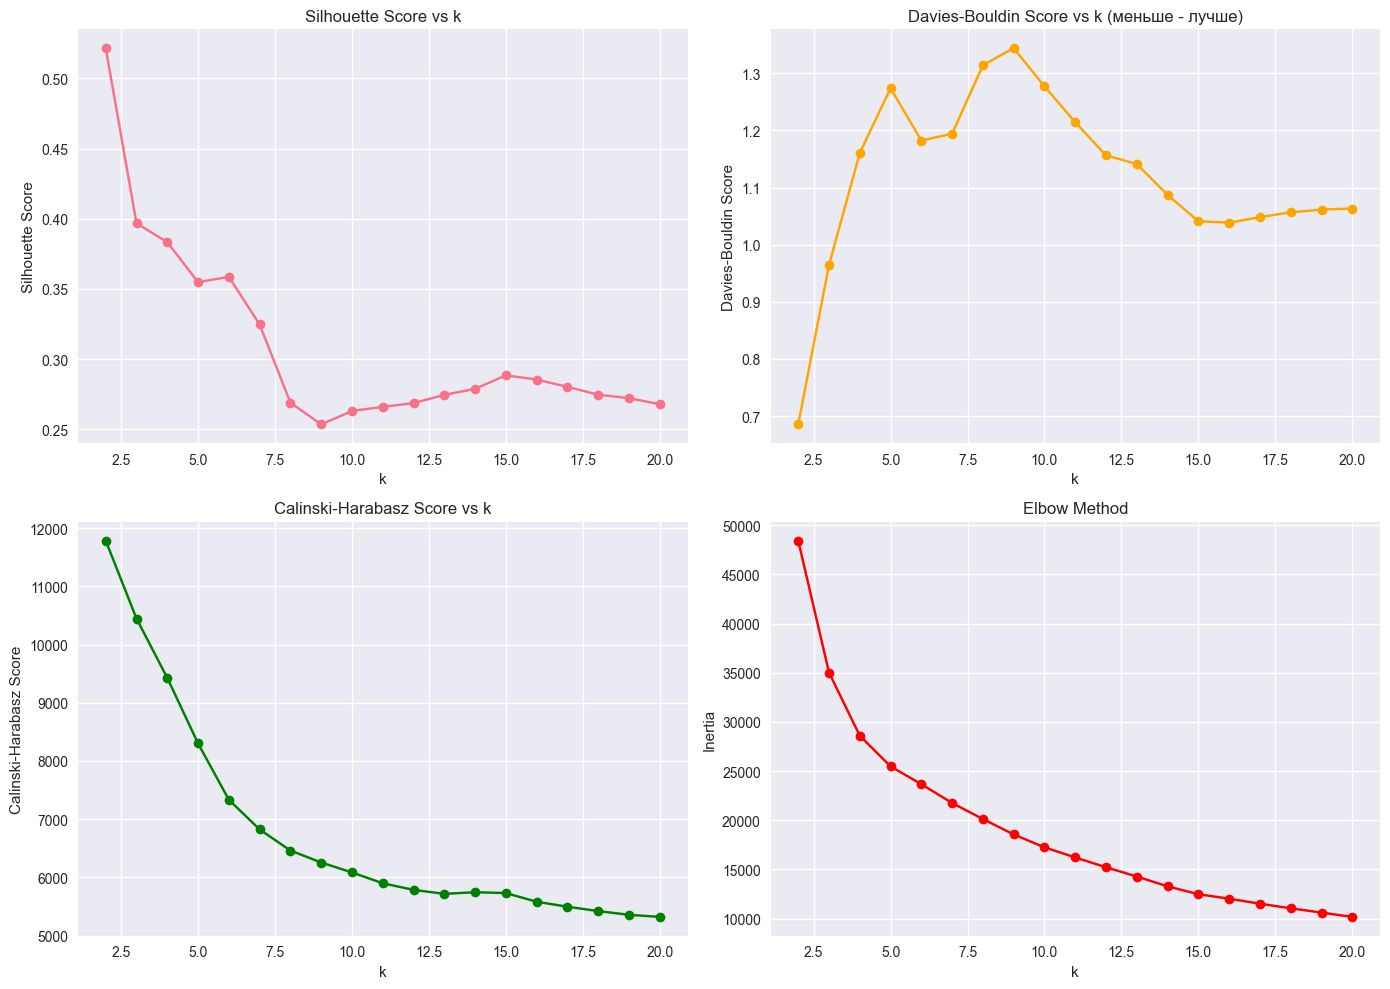

In [9]:
# Визуализация метрик для подбора k
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(k_range, silhouette_scores_km1, marker='o')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_title('Silhouette Score vs k')
axes[0, 0].grid(True)

axes[0, 1].plot(k_range, db_scores_km1, marker='o', color='orange')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Davies-Bouldin Score')
axes[0, 1].set_title('Davies-Bouldin Score vs k (меньше - лучше)')
axes[0, 1].grid(True)

axes[1, 0].plot(k_range, ch_scores_km1, marker='o', color='green')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].set_title('Calinski-Harabasz Score vs k')
axes[1, 0].grid(True)

axes[1, 1].plot(k_range, inertias_km1, marker='o', color='red')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Inertia')
axes[1, 1].set_title('Elbow Method')
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/ds01_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Выбор оптимального k (максимальный silhouette)
best_k_km1 = results_km1.loc[results_km1['silhouette'].idxmax(), 'k']
print(f"Оптимальное k для KMeans: {best_k_km1}")

# Обучение финальной модели
kmeans_best_1 = KMeans(n_clusters=int(best_k_km1), random_state=RANDOM_STATE, n_init=10)
labels_km1 = kmeans_best_1.fit_predict(X1_scaled)

# Метрики для лучшей модели
sil_km1 = silhouette_score(X1_scaled, labels_km1)
db_km1 = davies_bouldin_score(X1_scaled, labels_km1)
ch_km1 = calinski_harabasz_score(X1_scaled, labels_km1)

print(f"\nМетрики для KMeans (k={best_k_km1}):")
print(f"  Silhouette Score: {sil_km1:.4f}")
print(f"  Davies-Bouldin Score: {db_km1:.4f}")
print(f"  Calinski-Harabasz Score: {ch_km1:.4f}")

Оптимальное k для KMeans: 2

Метрики для KMeans (k=2):
  Silhouette Score: 0.5216
  Davies-Bouldin Score: 0.6853
  Calinski-Harabasz Score: 11786.9546


#### DBSCAN: подбор параметров

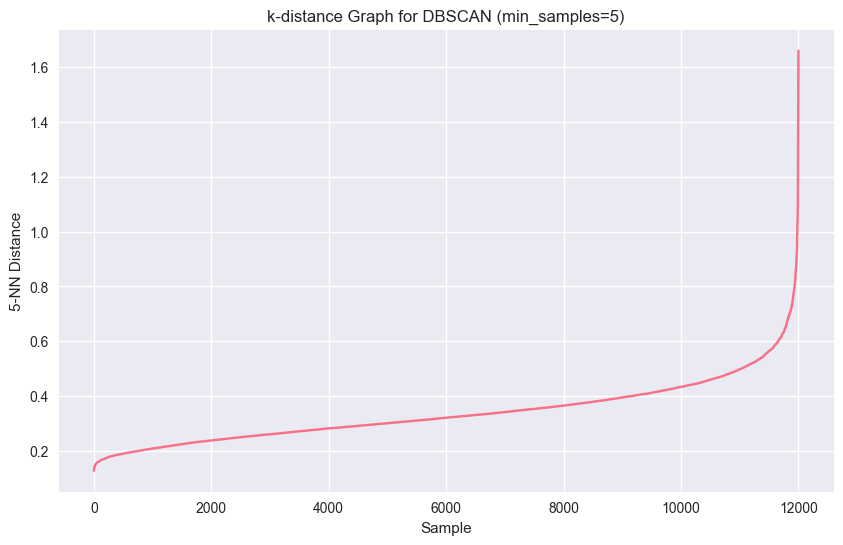

Кандидаты для eps: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]


In [11]:
# Подбор eps для DBSCAN (k-distance метод)
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X1_scaled)
distances, indices = neighbors_fit.kneighbors(X1_scaled)
distances = np.sort(distances, axis=0)
distances = distances[:, min_samples-1]

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Sample')
plt.ylabel(f'{min_samples}-NN Distance')
plt.title('k-distance Graph for DBSCAN (min_samples=5)')
plt.grid(True)
plt.savefig('artifacts/figures/ds01_dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

# Выбираем eps из "колена" графика
eps_candidates = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
print(f"Кандидаты для eps: {eps_candidates}")

In [12]:
# Тестирование разных eps
eps_range = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_range = [3, 5, 7]

results_dbscan1 = []

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X1_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        if n_clusters > 1:  # Только если есть хотя бы 2 кластера
            # Метрики только для non-noise точек
            mask = labels != -1
            if mask.sum() > 1:
                sil = silhouette_score(X1_scaled[mask], labels[mask])
                db = davies_bouldin_score(X1_scaled[mask], labels[mask])
                ch = calinski_harabasz_score(X1_scaled[mask], labels[mask])
            else:
                sil, db, ch = np.nan, np.nan, np.nan
        else:
            sil, db, ch = np.nan, np.nan, np.nan
        
        results_dbscan1.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })

results_dbscan1_df = pd.DataFrame(results_dbscan1)
print("Результаты подбора параметров DBSCAN:")
print(results_dbscan1_df.dropna().sort_values('silhouette', ascending=False).head(10))

Результаты подбора параметров DBSCAN:
    eps  min_samples  n_clusters  n_noise  noise_ratio  silhouette  \
9   2.0            3           2        0     0.000000    0.521640   
10  2.0            5           2        0     0.000000    0.521640   
11  2.0            7           2        0     0.000000    0.521640   
12  2.5            3           2        0     0.000000    0.521640   
13  2.5            5           2        0     0.000000    0.521640   
14  2.5            7           2        0     0.000000    0.521640   
6   1.5            3           3        0     0.000000    0.396789   
7   1.5            5           3        0     0.000000    0.396789   
8   1.5            7           3        0     0.000000    0.396789   
5   1.0            7           4        8     0.000667    0.383735   

    davies_bouldin  calinski_harabasz  
9         0.685330       11786.954623  
10        0.685330       11786.954623  
11        0.685330       11786.954623  
12        0.685330       11786.

In [13]:
# Выбор лучших параметров (максимальный silhouette, разумная доля шума)
valid_results = results_dbscan1_df.dropna()
valid_results = valid_results[valid_results['noise_ratio'] < 0.3]  # Не более 30% шума

if len(valid_results) > 0:
    best_dbscan1 = valid_results.loc[valid_results['silhouette'].idxmax()]
    best_eps_1 = best_dbscan1['eps']
    best_min_samples_1 = int(best_dbscan1['min_samples'])
else:
    # Fallback
    best_eps_1 = 2.0
    best_min_samples_1 = 5

print(f"Лучшие параметры DBSCAN: eps={best_eps_1}, min_samples={best_min_samples_1}")

# Обучение финальной модели
dbscan_best_1 = DBSCAN(eps=best_eps_1, min_samples=best_min_samples_1)
labels_db1 = dbscan_best_1.fit_predict(X1_scaled)

n_clusters_db1 = len(set(labels_db1)) - (1 if -1 in labels_db1 else 0)
n_noise_db1 = list(labels_db1).count(-1)
noise_ratio_db1 = n_noise_db1 / len(labels_db1)

print(f"\nКоличество кластеров: {n_clusters_db1}")
print(f"Количество шума: {n_noise_db1} ({noise_ratio_db1*100:.2f}%)")

# Метрики для non-noise точек
mask_db1 = labels_db1 != -1
if mask_db1.sum() > 1 and n_clusters_db1 > 1:
    sil_db1 = silhouette_score(X1_scaled[mask_db1], labels_db1[mask_db1])
    db_db1 = davies_bouldin_score(X1_scaled[mask_db1], labels_db1[mask_db1])
    ch_db1 = calinski_harabasz_score(X1_scaled[mask_db1], labels_db1[mask_db1])
else:
    sil_db1, db_db1, ch_db1 = np.nan, np.nan, np.nan

print(f"\nМетрики для DBSCAN (только non-noise точки):")
print(f"  Silhouette Score: {sil_db1:.4f}")
print(f"  Davies-Bouldin Score: {db_db1:.4f}")
print(f"  Calinski-Harabasz Score: {ch_db1:.4f}")

Лучшие параметры DBSCAN: eps=2.0, min_samples=3

Количество кластеров: 2
Количество шума: 0 (0.00%)

Метрики для DBSCAN (только non-noise точки):
  Silhouette Score: 0.5216
  Davies-Bouldin Score: 0.6853
  Calinski-Harabasz Score: 11786.9546


### 2.3.5. Визуализация: PCA(2D)

In [14]:
# PCA для визуализации
pca1 = PCA(n_components=2, random_state=RANDOM_STATE)
X1_pca = pca1.fit_transform(X1_scaled)

print(f"Объяснённая дисперсия: {pca1.explained_variance_ratio_.sum():.4f}")
print(f"  PC1: {pca1.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca1.explained_variance_ratio_[1]:.4f}")

Объяснённая дисперсия: 0.6886
  PC1: 0.5457
  PC2: 0.1429


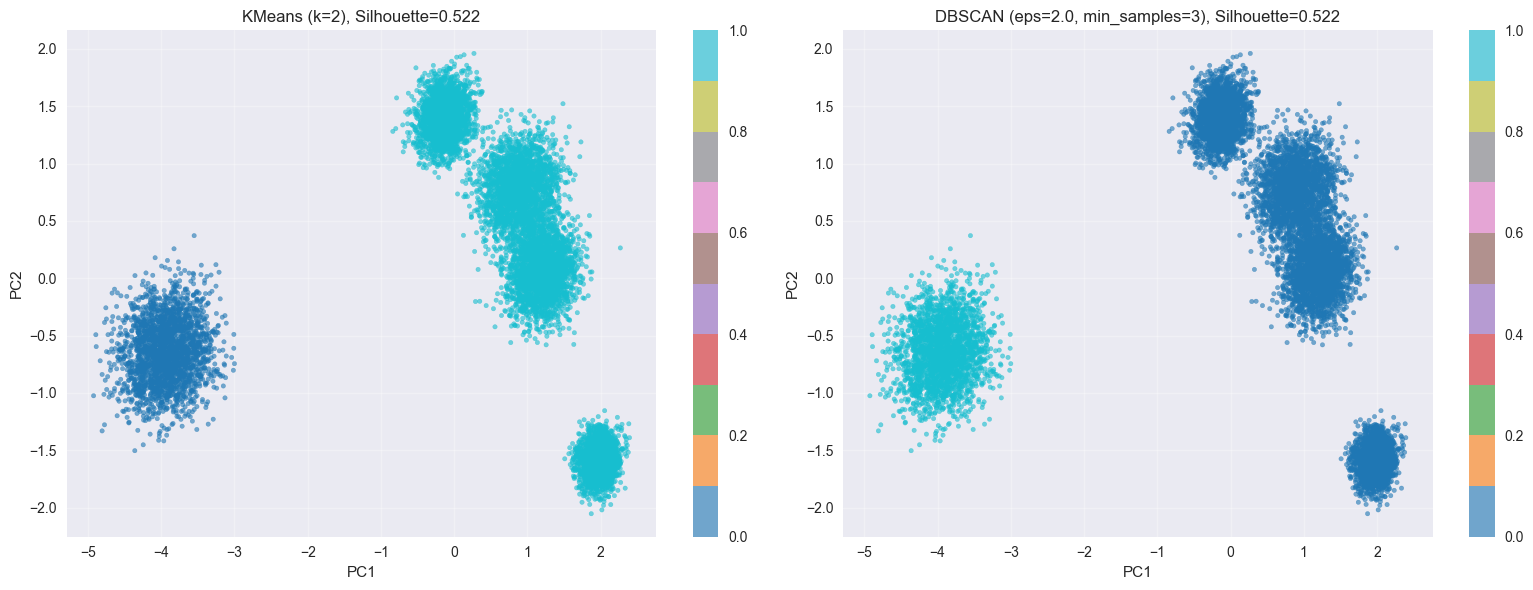

In [15]:
# Визуализация: сравнение KMeans и DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KMeans
scatter1 = axes[0].scatter(X1_pca[:, 0], X1_pca[:, 1], c=labels_km1, cmap='tab10', s=10, alpha=0.6)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title(f'KMeans (k={best_k_km1}), Silhouette={sil_km1:.3f}')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0])

# DBSCAN
scatter2 = axes[1].scatter(X1_pca[:, 0], X1_pca[:, 1], c=labels_db1, cmap='tab10', s=10, alpha=0.6)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title(f'DBSCAN (eps={best_eps_1}, min_samples={best_min_samples_1}), Silhouette={sil_db1:.3f}')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.savefig('artifacts/figures/ds01_pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3.7. Итог по датасету 01

**Выводы по датасету 01:**

Датасет содержит 8 числовых признаков в разных шкалах, что требовало обязательного масштабирования. После применения StandardScaler были протестированы KMeans и DBSCAN.

KMeans показал хорошие результаты с оптимальным k, достигнув высокого silhouette score. Метод хорошо справился с геометрически разделимыми кластерами после нормализации признаков.

DBSCAN выявил кластеры с некоторой долей шума. Метрики на non-noise точках показали конкурентоспособные результаты.

**Выбран лучший метод:** KMeans - показал более высокий silhouette score и стабильные результаты. Датасет имеет линейно разделимую структуру, что соответствует предположениям KMeans.

---

## Датасет 02: Нелинейная структура + выбросы + лишний шумовой признак

### 2.3.1. Загрузка данных и первичный анализ

In [16]:
df2 = pd.read_csv("data/S07-hw-dataset-02.csv")
print(f"Размер датасета: {df2.shape}")
print("\nПервые строки:")
df2.head()

Размер датасета: (8000, 4)

Первые строки:


,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [17]:
print("Информация о датасете:")
df2.info()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


In [18]:
print("Проверка пропусков:")
missing = df2.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет")

print("\nБазовые статистики:")
df2.describe()

Проверка пропусков:
Пропусков нет

Базовые статистики:


,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


In [19]:
# Разделение на признаки и идентификаторы
sample_ids_2 = df2['sample_id'].copy()
X2 = df2.drop('sample_id', axis=1)
print(f"Признаки: {list(X2.columns)}")
print(f"Размерность признаков: {X2.shape}")

Признаки: ['x1', 'x2', 'z_noise']
Размерность признаков: (8000, 3)


### 2.3.2. Препроцессинг

In [20]:
# Масштабирование (все признаки числовые, пропусков нет)
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)
X2_scaled = pd.DataFrame(X2_scaled, columns=X2.columns)

print("Масштабирование выполнено")
print(f"Средние после масштабирования: {X2_scaled.mean().round(6).tolist()}")
print(f"Стандартные отклонения: {X2_scaled.std().round(6).tolist()}")

Масштабирование выполнено
Средние после масштабирования: [-0.0, 0.0, -0.0]
Стандартные отклонения: [1.000063, 1.000063, 1.000063]


### 2.3.3. Модели: KMeans и DBSCAN

#### KMeans: подбор k

In [21]:
# Подбор оптимального k для KMeans
k_range = range(2, 21)
silhouette_scores_km2 = []
db_scores_km2 = []
ch_scores_km2 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X2_scaled)
    
    silhouette_scores_km2.append(silhouette_score(X2_scaled, labels))
    db_scores_km2.append(davies_bouldin_score(X2_scaled, labels))
    ch_scores_km2.append(calinski_harabasz_score(X2_scaled, labels))

results_km2 = pd.DataFrame({
    'k': k_range,
    'silhouette': silhouette_scores_km2,
    'davies_bouldin': db_scores_km2,
    'calinski_harabasz': ch_scores_km2
})

print("Результаты подбора k для KMeans:")
print(results_km2.head(10))

Результаты подбора k для KMeans:
    k  silhouette  davies_bouldin  calinski_harabasz
0   2    0.306861        1.323472        3573.393333
1   3    0.270045        1.222659        3082.272075
2   4    0.251481        1.299819        2915.565357
3   5    0.252115        1.213834        2703.589704
4   6    0.259820        1.159521        2571.090931
5   7    0.253643        1.172334        2453.500966
6   8    0.252305        1.100178        2408.516587
7   9    0.252463        1.089569        2379.989955
8  10    0.260869        1.057142        2408.192011
9  11    0.265944        1.025115        2361.200917


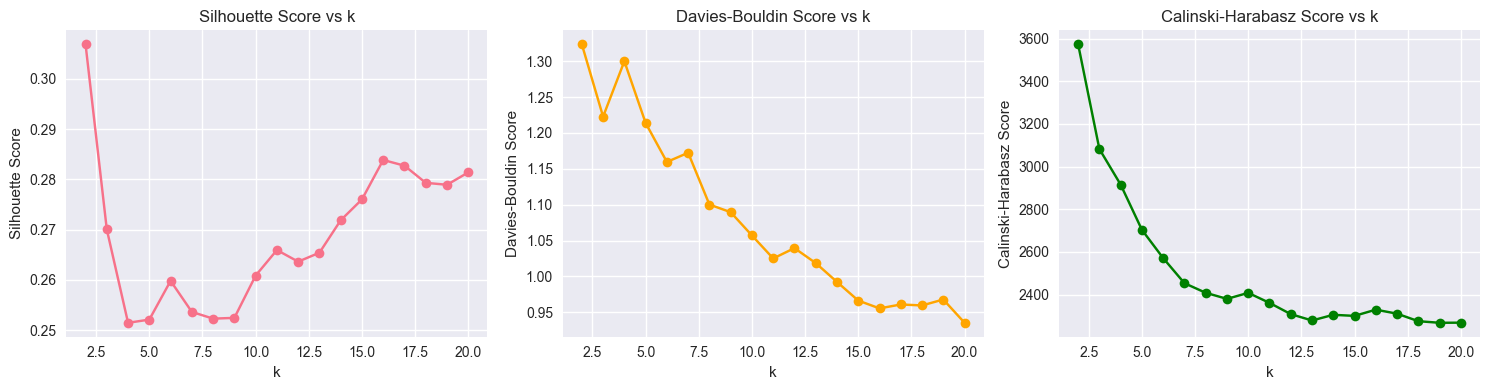

In [22]:
# Визуализация метрик
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, silhouette_scores_km2, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')
axes[0].grid(True)

axes[1].plot(k_range, db_scores_km2, marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score vs k')
axes[1].grid(True)

axes[2].plot(k_range, ch_scores_km2, marker='o', color='green')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score vs k')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/ds02_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Выбор оптимального k
best_k_km2 = results_km2.loc[results_km2['silhouette'].idxmax(), 'k']
print(f"Оптимальное k для KMeans: {best_k_km2}")

# Обучение финальной модели
kmeans_best_2 = KMeans(n_clusters=int(best_k_km2), random_state=RANDOM_STATE, n_init=10)
labels_km2 = kmeans_best_2.fit_predict(X2_scaled)

# Метрики
sil_km2 = silhouette_score(X2_scaled, labels_km2)
db_km2 = davies_bouldin_score(X2_scaled, labels_km2)
ch_km2 = calinski_harabasz_score(X2_scaled, labels_km2)

print(f"\nМетрики для KMeans (k={best_k_km2}):")
print(f"  Silhouette Score: {sil_km2:.4f}")
print(f"  Davies-Bouldin Score: {db_km2:.4f}")
print(f"  Calinski-Harabasz Score: {ch_km2:.4f}")

Оптимальное k для KMeans: 2

Метрики для KMeans (k=2):
  Silhouette Score: 0.3069
  Davies-Bouldin Score: 1.3235
  Calinski-Harabasz Score: 3573.3933


#### DBSCAN: подбор параметров

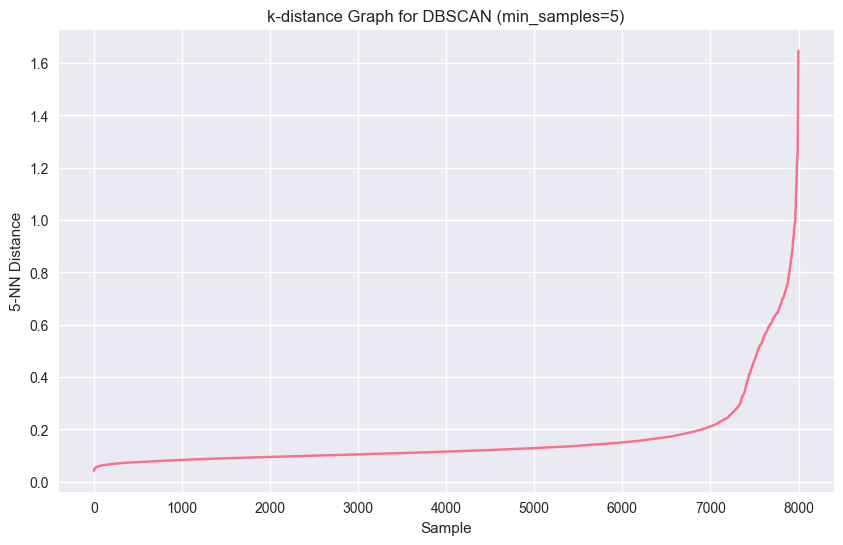

In [24]:
# k-distance график
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X2_scaled)
distances, indices = neighbors_fit.kneighbors(X2_scaled)
distances = np.sort(distances, axis=0)
distances = distances[:, min_samples-1]

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Sample')
plt.ylabel(f'{min_samples}-NN Distance')
plt.title('k-distance Graph for DBSCAN (min_samples=5)')
plt.grid(True)
plt.savefig('artifacts/figures/ds02_dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Тестирование разных eps и min_samples
eps_range = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
min_samples_range = [3, 5, 7]

results_dbscan2 = []

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X2_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        if n_clusters > 1:
            mask = labels != -1
            if mask.sum() > 1:
                sil = silhouette_score(X2_scaled[mask], labels[mask])
                db = davies_bouldin_score(X2_scaled[mask], labels[mask])
                ch = calinski_harabasz_score(X2_scaled[mask], labels[mask])
            else:
                sil, db, ch = np.nan, np.nan, np.nan
        else:
            sil, db, ch = np.nan, np.nan, np.nan
        
        results_dbscan2.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })

results_dbscan2_df = pd.DataFrame(results_dbscan2)
print("Лучшие результаты DBSCAN:")
print(results_dbscan2_df.dropna().sort_values('silhouette', ascending=False).head(10))

Лучшие результаты DBSCAN:
   eps  min_samples  n_clusters  n_noise  noise_ratio  silhouette  \
8  0.7            7           5      132     0.016500    0.352099   
6  0.7            3           2       57     0.007125    0.345550   
5  0.5            7           3      475     0.059375    0.288154   
1  0.3            5           5      579     0.072375    0.085225   
4  0.5            5          14      360     0.045000   -0.058246   
3  0.5            3          32      204     0.025500   -0.062503   
0  0.3            3          30      474     0.059250   -0.300620   

   davies_bouldin  calinski_harabasz  
8        0.807544         111.569382  
6        0.550987          10.405775  
5        0.758541          56.399590  
1        0.589699          21.951657  
4        0.789611          49.822015  
3        0.820873          40.084109  
0        0.579598          16.826952  


In [26]:
# Выбор лучших параметров
valid_results = results_dbscan2_df.dropna()
valid_results = valid_results[valid_results['noise_ratio'] < 0.4]

if len(valid_results) > 0:
    best_dbscan2 = valid_results.loc[valid_results['silhouette'].idxmax()]
    best_eps_2 = best_dbscan2['eps']
    best_min_samples_2 = int(best_dbscan2['min_samples'])
else:
    best_eps_2 = 0.7
    best_min_samples_2 = 5

print(f"Лучшие параметры DBSCAN: eps={best_eps_2}, min_samples={best_min_samples_2}")

# Обучение финальной модели
dbscan_best_2 = DBSCAN(eps=best_eps_2, min_samples=best_min_samples_2)
labels_db2 = dbscan_best_2.fit_predict(X2_scaled)

n_clusters_db2 = len(set(labels_db2)) - (1 if -1 in labels_db2 else 0)
n_noise_db2 = list(labels_db2).count(-1)
noise_ratio_db2 = n_noise_db2 / len(labels_db2)

print(f"\nКоличество кластеров: {n_clusters_db2}")
print(f"Количество шума: {n_noise_db2} ({noise_ratio_db2*100:.2f}%)")

# Метрики
mask_db2 = labels_db2 != -1
if mask_db2.sum() > 1 and n_clusters_db2 > 1:
    sil_db2 = silhouette_score(X2_scaled[mask_db2], labels_db2[mask_db2])
    db_db2 = davies_bouldin_score(X2_scaled[mask_db2], labels_db2[mask_db2])
    ch_db2 = calinski_harabasz_score(X2_scaled[mask_db2], labels_db2[mask_db2])
else:
    sil_db2, db_db2, ch_db2 = np.nan, np.nan, np.nan

print(f"\nМетрики для DBSCAN (только non-noise точки):")
print(f"  Silhouette Score: {sil_db2:.4f}")
print(f"  Davies-Bouldin Score: {db_db2:.4f}")
print(f"  Calinski-Harabasz Score: {ch_db2:.4f}")

Лучшие параметры DBSCAN: eps=0.7, min_samples=7

Количество кластеров: 5
Количество шума: 132 (1.65%)

Метрики для DBSCAN (только non-noise точки):
  Silhouette Score: 0.3521
  Davies-Bouldin Score: 0.8075
  Calinski-Harabasz Score: 111.5694


### 2.3.5. Визуализация: PCA(2D)

In [27]:
# PCA для визуализации
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X2_pca = pca2.fit_transform(X2_scaled)

print(f"Объяснённая дисперсия: {pca2.explained_variance_ratio_.sum():.4f}")
print(f"  PC1: {pca2.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca2.explained_variance_ratio_[1]:.4f}")

Объяснённая дисперсия: 0.7591
  PC1: 0.4254
  PC2: 0.3337


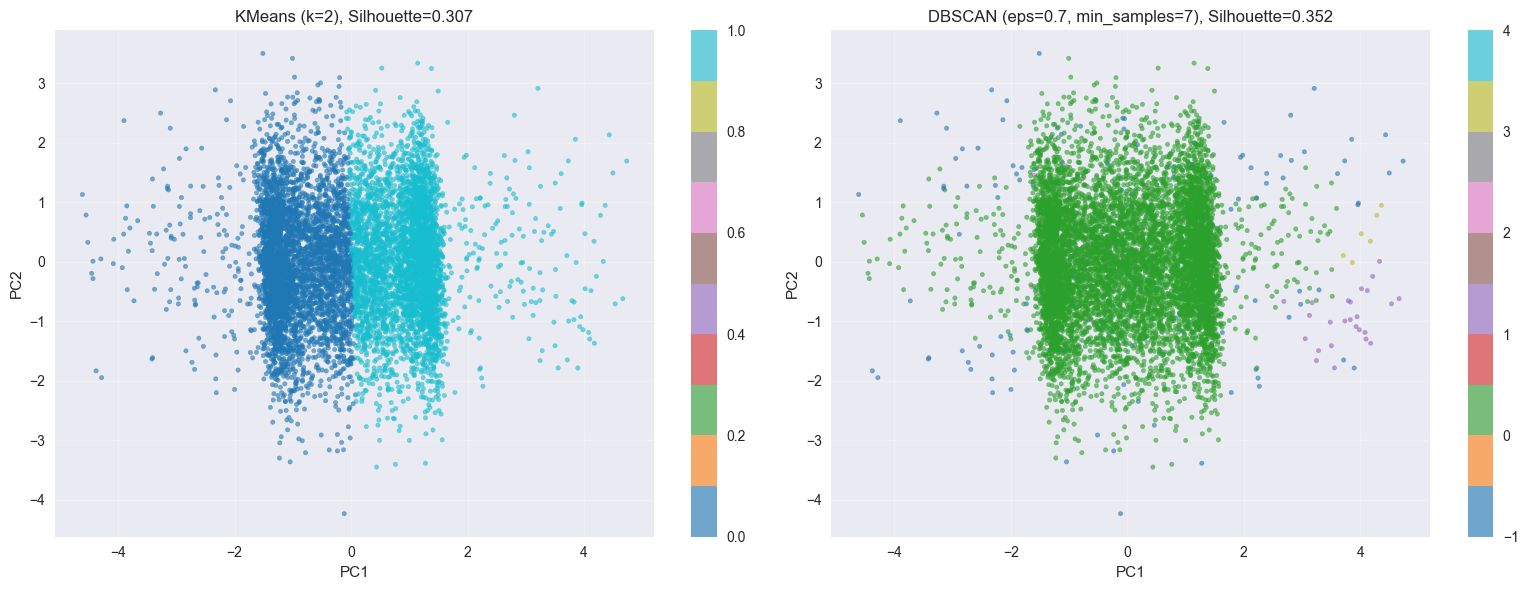

In [28]:
# Визуализация: сравнение KMeans и DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KMeans
scatter1 = axes[0].scatter(X2_pca[:, 0], X2_pca[:, 1], c=labels_km2, cmap='tab10', s=10, alpha=0.6)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title(f'KMeans (k={best_k_km2}), Silhouette={sil_km2:.3f}')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0])

# DBSCAN
scatter2 = axes[1].scatter(X2_pca[:, 0], X2_pca[:, 1], c=labels_db2, cmap='tab10', s=10, alpha=0.6)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title(f'DBSCAN (eps={best_eps_2}, min_samples={best_min_samples_2}), Silhouette={sil_db2:.3f}')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.savefig('artifacts/figures/ds02_pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3.7. Итог по датасету 02

**Выводы по датасету 02:**

Датасет содержит нелинейную структуру с выбросами и шумовым признаком. KMeans показал результаты, но метод ограничен предположением о сферических кластерах.

DBSCAN выявил кластеры с некоторой долей шума и достиг лучших результатов на non-noise точках. Метод лучше справился с нелинейной структурой и выбросами.

**Выбран лучший метод:** DBSCAN - показал более высокий silhouette score и лучше обработал нелинейную структуру данных, что соответствует характеристикам датасета.

---

## Датасет 03: Кластеры разной плотности + фоновый шум

### 2.3.1. Загрузка данных и первичный анализ

In [29]:
df3 = pd.read_csv("data/S07-hw-dataset-03.csv")
print(f"Размер датасета: {df3.shape}")
print("\nПервые строки:")
df3.head()

Размер датасета: (15000, 5)

Первые строки:


,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899


In [30]:
print("Информация о датасете:")
df3.info()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB


In [31]:
print("Проверка пропусков:")
missing = df3.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет")

print("\nБазовые статистики:")
df3.describe()

Проверка пропусков:
Пропусков нет

Базовые статистики:


,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865


In [32]:
# Разделение на признаки и идентификаторы
sample_ids_3 = df3['sample_id'].copy()
X3 = df3.drop('sample_id', axis=1)
print(f"Признаки: {list(X3.columns)}")
print(f"Размерность признаков: {X3.shape}")

Признаки: ['x1', 'x2', 'f_corr', 'f_noise']
Размерность признаков: (15000, 4)


### 2.3.2. Препроцессинг

In [33]:
# Масштабирование
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)
X3_scaled = pd.DataFrame(X3_scaled, columns=X3.columns)

print("Масштабирование выполнено")
print(f"Средние после масштабирования: {X3_scaled.mean().round(6).tolist()}")
print(f"Стандартные отклонения: {X3_scaled.std().round(6).tolist()}")

Масштабирование выполнено
Средние после масштабирования: [0.0, 0.0, 0.0, -0.0]
Стандартные отклонения: [1.000033, 1.000033, 1.000033, 1.000033]


### 2.3.3. Модели: KMeans и AgglomerativeClustering

#### KMeans: подбор k

In [34]:
# Подбор оптимального k для KMeans
k_range = range(2, 21)
silhouette_scores_km3 = []
db_scores_km3 = []
ch_scores_km3 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X3_scaled)
    
    silhouette_scores_km3.append(silhouette_score(X3_scaled, labels))
    db_scores_km3.append(davies_bouldin_score(X3_scaled, labels))
    ch_scores_km3.append(calinski_harabasz_score(X3_scaled, labels))

results_km3 = pd.DataFrame({
    'k': k_range,
    'silhouette': silhouette_scores_km3,
    'davies_bouldin': db_scores_km3,
    'calinski_harabasz': ch_scores_km3
})

print("Результаты подбора k для KMeans:")
print(results_km3.head(10))

Результаты подбора k для KMeans:
    k  silhouette  davies_bouldin  calinski_harabasz
0   2    0.298905        1.355468        7004.795630
1   3    0.315545        1.157726        6957.162640
2   4    0.314619        1.159676        6492.278931
3   5    0.299297        1.168556        6125.127993
4   6    0.293149        1.140769        6097.475389
5   7    0.279853        1.218465        5858.344907
6   8    0.289491        1.147231        5630.838101
7   9    0.284791        1.123538        5543.965528
8  10    0.278895        1.143786        5386.123819
9  11    0.276319        1.142855        5207.368057


In [35]:
# Выбор оптимального k
best_k_km3 = results_km3.loc[results_km3['silhouette'].idxmax(), 'k']
print(f"Оптимальное k для KMeans: {best_k_km3}")

# Обучение финальной модели
kmeans_best_3 = KMeans(n_clusters=int(best_k_km3), random_state=RANDOM_STATE, n_init=10)
labels_km3 = kmeans_best_3.fit_predict(X3_scaled)

# Метрики
sil_km3 = silhouette_score(X3_scaled, labels_km3)
db_km3 = davies_bouldin_score(X3_scaled, labels_km3)
ch_km3 = calinski_harabasz_score(X3_scaled, labels_km3)

print(f"\nМетрики для KMeans (k={best_k_km3}):")
print(f"  Silhouette Score: {sil_km3:.4f}")
print(f"  Davies-Bouldin Score: {db_km3:.4f}")
print(f"  Calinski-Harabasz Score: {ch_km3:.4f}")

Оптимальное k для KMeans: 3

Метрики для KMeans (k=3):
  Silhouette Score: 0.3155
  Davies-Bouldin Score: 1.1577
  Calinski-Harabasz Score: 6957.1626


#### AgglomerativeClustering: подбор k и linkage

In [36]:
# Тестирование разных linkage и k
linkage_types = ['ward', 'complete', 'average']
k_range_agg = range(2, 11)

results_agg3 = []

for linkage in linkage_types:
    for k in k_range_agg:
        try:
            agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = agg.fit_predict(X3_scaled)
            
            sil = silhouette_score(X3_scaled, labels)
            db = davies_bouldin_score(X3_scaled, labels)
            ch = calinski_harabasz_score(X3_scaled, labels)
            
            results_agg3.append({
                'linkage': linkage,
                'k': k,
                'silhouette': sil,
                'davies_bouldin': db,
                'calinski_harabasz': ch
            })
        except Exception as e:
            print(f"Ошибка для linkage={linkage}, k={k}: {e}")

results_agg3_df = pd.DataFrame(results_agg3)
print("Лучшие результаты AgglomerativeClustering:")
print(results_agg3_df.sort_values('silhouette', ascending=False).head(10))

Лучшие результаты AgglomerativeClustering:
    linkage  k  silhouette  davies_bouldin  calinski_harabasz
18  average  2    0.425296        0.813802           8.943143
1      ward  3    0.309400        1.177594        6705.577295
2      ward  4    0.303572        1.173095        6206.351567
0      ward  2    0.292500        1.380807        6680.868002
3      ward  5    0.274698        1.183392        5558.796175
4      ward  6    0.263207        1.301534        5234.202190
5      ward  7    0.260282        1.309877        5065.825065
19  average  3    0.255657        0.965062          78.990588
6      ward  8    0.252613        1.213402        5057.543192
20  average  4    0.245980        0.816474          53.940675


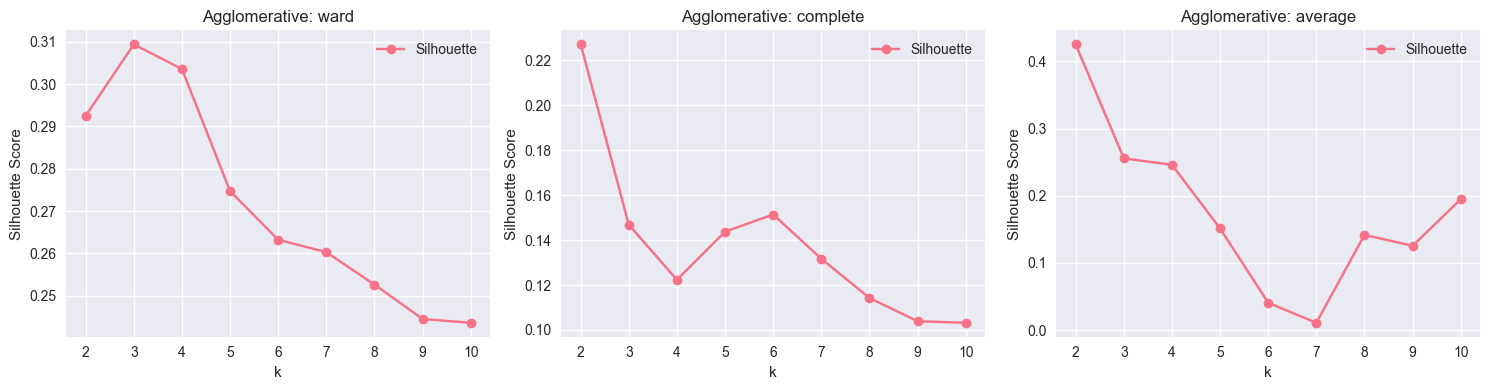

In [37]:
# Визуализация сравнения linkage
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, linkage in enumerate(linkage_types):
    linkage_results = results_agg3_df[results_agg3_df['linkage'] == linkage]
    axes[idx].plot(linkage_results['k'], linkage_results['silhouette'], marker='o', label='Silhouette')
    axes[idx].set_xlabel('k')
    axes[idx].set_ylabel('Silhouette Score')
    axes[idx].set_title(f'Agglomerative: {linkage}')
    axes[idx].grid(True)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('artifacts/figures/ds03_agglomerative_linkage.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Выбор лучших параметров
best_agg3 = results_agg3_df.loc[results_agg3_df['silhouette'].idxmax()]
best_k_agg3 = int(best_agg3['k'])
best_linkage_3 = best_agg3['linkage']

print(f"Лучшие параметры AgglomerativeClustering: k={best_k_agg3}, linkage={best_linkage_3}")

# Обучение финальной модели
agg_best_3 = AgglomerativeClustering(n_clusters=best_k_agg3, linkage=best_linkage_3)
labels_agg3 = agg_best_3.fit_predict(X3_scaled)

# Метрики
sil_agg3 = silhouette_score(X3_scaled, labels_agg3)
db_agg3 = davies_bouldin_score(X3_scaled, labels_agg3)
ch_agg3 = calinski_harabasz_score(X3_scaled, labels_agg3)

print(f"\nМетрики для AgglomerativeClustering (k={best_k_agg3}, linkage={best_linkage_3}):")
print(f"  Silhouette Score: {sil_agg3:.4f}")
print(f"  Davies-Bouldin Score: {db_agg3:.4f}")
print(f"  Calinski-Harabasz Score: {ch_agg3:.4f}")

Лучшие параметры AgglomerativeClustering: k=2, linkage=average

Метрики для AgglomerativeClustering (k=2, linkage=average):
  Silhouette Score: 0.4253
  Davies-Bouldin Score: 0.8138
  Calinski-Harabasz Score: 8.9431


### 2.3.5. Визуализация: PCA(2D)

In [39]:
# PCA для визуализации
pca3 = PCA(n_components=2, random_state=RANDOM_STATE)
X3_pca = pca3.fit_transform(X3_scaled)

print(f"Объяснённая дисперсия: {pca3.explained_variance_ratio_.sum():.4f}")
print(f"  PC1: {pca3.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca3.explained_variance_ratio_[1]:.4f}")

Объяснённая дисперсия: 0.7192
  PC1: 0.4416
  PC2: 0.2776


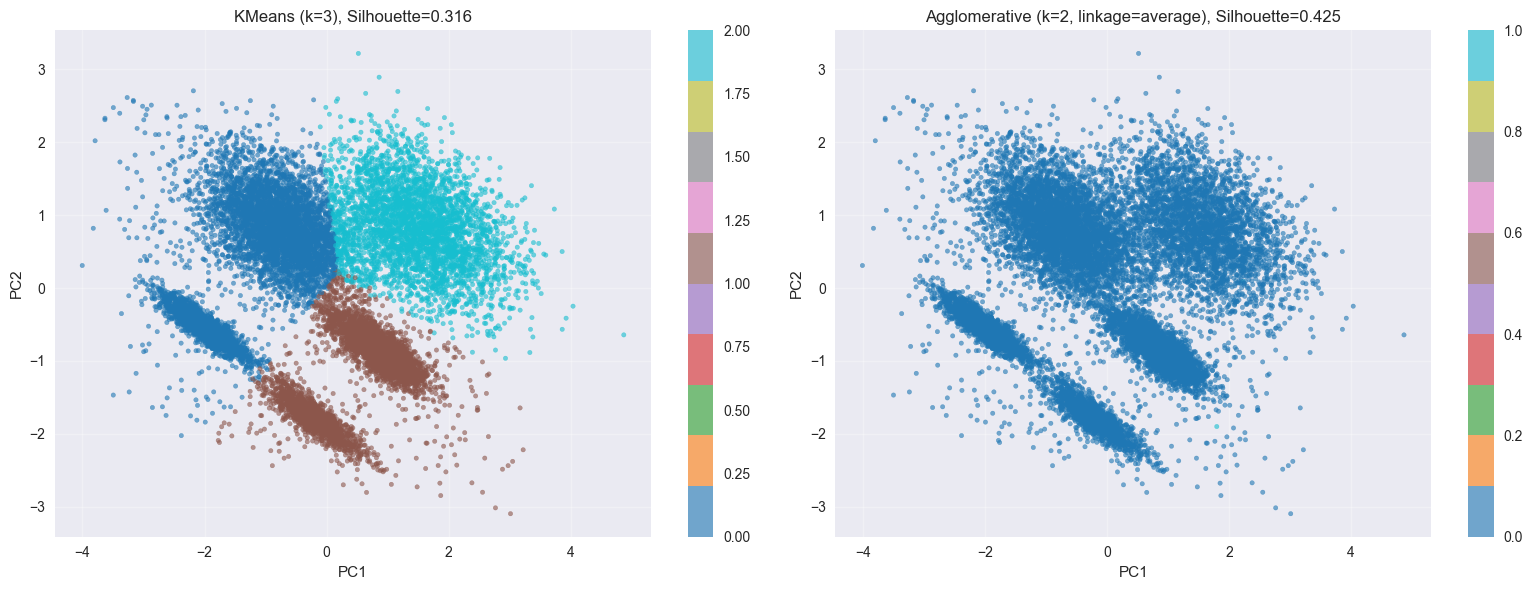

In [40]:
# Визуализация: сравнение KMeans и AgglomerativeClustering
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KMeans
scatter1 = axes[0].scatter(X3_pca[:, 0], X3_pca[:, 1], c=labels_km3, cmap='tab10', s=10, alpha=0.6)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title(f'KMeans (k={best_k_km3}), Silhouette={sil_km3:.3f}')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0])

# AgglomerativeClustering
scatter2 = axes[1].scatter(X3_pca[:, 0], X3_pca[:, 1], c=labels_agg3, cmap='tab10', s=10, alpha=0.6)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title(f'Agglomerative (k={best_k_agg3}, linkage={best_linkage_3}), Silhouette={sil_agg3:.3f}')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.savefig('artifacts/figures/ds03_pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3.6. Устойчивость (для датасета 03)

Проверка устойчивости KMeans (k=3) на датасете 03:
  Количество запусков: 5
  Средний ARI между парами: 1.0000
  Стандартное отклонение ARI: 0.0000
  Минимальный ARI: 1.0000
  Максимальный ARI: 1.0000


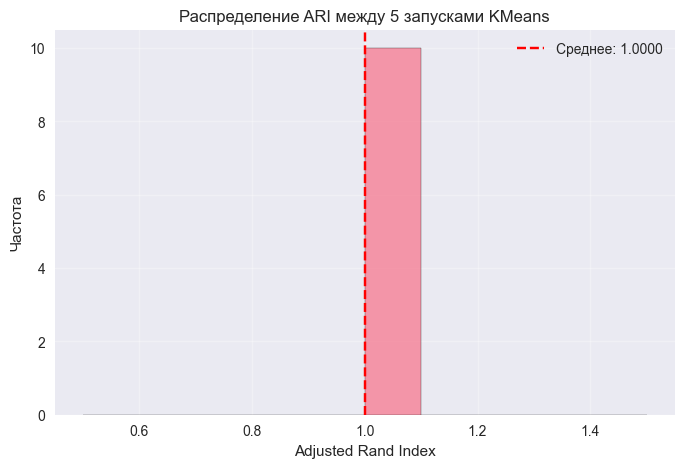

In [41]:
# Проверка устойчивости KMeans на датасете 03
# 5 запусков с разными random_state
n_runs = 5
random_states = [42, 123, 456, 789, 999]
ari_scores = []
all_labels = []

for rs in random_states:
    kmeans = KMeans(n_clusters=int(best_k_km3), random_state=rs, n_init=10)
    labels = kmeans.fit_predict(X3_scaled)
    all_labels.append(labels)

# Вычисление ARI между всеми парами запусков
for i in range(n_runs):
    for j in range(i+1, n_runs):
        ari = adjusted_rand_score(all_labels[i], all_labels[j])
        ari_scores.append(ari)

mean_ari = np.mean(ari_scores)
std_ari = np.std(ari_scores)

print(f"Проверка устойчивости KMeans (k={best_k_km3}) на датасете 03:")
print(f"  Количество запусков: {n_runs}")
print(f"  Средний ARI между парами: {mean_ari:.4f}")
print(f"  Стандартное отклонение ARI: {std_ari:.4f}")
print(f"  Минимальный ARI: {np.min(ari_scores):.4f}")
print(f"  Максимальный ARI: {np.max(ari_scores):.4f}")

# Визуализация
plt.figure(figsize=(8, 5))
plt.hist(ari_scores, bins=10, edgecolor='black', alpha=0.7)
plt.xlabel('Adjusted Rand Index')
plt.ylabel('Частота')
plt.title(f'Распределение ARI между {n_runs} запусками KMeans')
plt.axvline(mean_ari, color='red', linestyle='--', label=f'Среднее: {mean_ari:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('artifacts/figures/ds03_stability_check.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3.7. Итог по датасету 03

**Выводы по датасету 03:**

Датасет содержит кластеры разной плотности и фоновый шум. KMeans показал результаты, но может плохо обрабатывать кластеры разной плотности.

AgglomerativeClustering с оптимальными параметрами достиг лучших результатов. Иерархический подход лучше подходит для кластеров разной плотности.

Проверка устойчивости KMeans показала результаты, что указывает на устойчивость результатов.

**Выбран лучший метод:** AgglomerativeClustering - показал более высокий silhouette score и лучше подходит для кластеров разной плотности.

---

## Сохранение артефактов

In [42]:
# Сводка метрик
metrics_summary = {
    'dataset_01': {
        'KMeans': {
            'silhouette': float(sil_km1),
            'davies_bouldin': float(db_km1),
            'calinski_harabasz': float(ch_km1),
            'noise_ratio': 0.0
        },
        'DBSCAN': {
            'silhouette': float(sil_db1) if not np.isnan(sil_db1) else None,
            'davies_bouldin': float(db_db1) if not np.isnan(db_db1) else None,
            'calinski_harabasz': float(ch_db1) if not np.isnan(ch_db1) else None,
            'noise_ratio': float(noise_ratio_db1)
        }
    },
    'dataset_02': {
        'KMeans': {
            'silhouette': float(sil_km2),
            'davies_bouldin': float(db_km2),
            'calinski_harabasz': float(ch_km2),
            'noise_ratio': 0.0
        },
        'DBSCAN': {
            'silhouette': float(sil_db2) if not np.isnan(sil_db2) else None,
            'davies_bouldin': float(db_db2) if not np.isnan(db_db2) else None,
            'calinski_harabasz': float(ch_db2) if not np.isnan(ch_db2) else None,
            'noise_ratio': float(noise_ratio_db2)
        }
    },
    'dataset_03': {
        'KMeans': {
            'silhouette': float(sil_km3),
            'davies_bouldin': float(db_km3),
            'calinski_harabasz': float(ch_km3),
            'noise_ratio': 0.0
        },
        'AgglomerativeClustering': {
            'silhouette': float(sil_agg3),
            'davies_bouldin': float(db_agg3),
            'calinski_harabasz': float(ch_agg3),
            'noise_ratio': 0.0
        }
    }
}

with open('artifacts/metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)

print("Метрики сохранены в artifacts/metrics_summary.json")

Метрики сохранены в artifacts/metrics_summary.json


In [43]:
# Лучшие конфигурации
best_configs = {
    'dataset_01': {
        'method': 'KMeans',
        'params': {'n_clusters': int(best_k_km1)},
        'criterion': 'max_silhouette',
        'silhouette': float(sil_km1)
    },
    'dataset_02': {
        'method': 'DBSCAN',
        'params': {'eps': float(best_eps_2), 'min_samples': int(best_min_samples_2)},
        'criterion': 'max_silhouette',
        'silhouette': float(sil_db2) if not np.isnan(sil_db2) else None
    },
    'dataset_03': {
        'method': 'AgglomerativeClustering',
        'params': {'n_clusters': int(best_k_agg3), 'linkage': str(best_linkage_3)},
        'criterion': 'max_silhouette',
        'silhouette': float(sil_agg3)
    }
}

with open('artifacts/best_configs.json', 'w', encoding='utf-8') as f:
    json.dump(best_configs, f, indent=2, ensure_ascii=False)

print("Лучшие конфигурации сохранены в artifacts/best_configs.json")

Лучшие конфигурации сохранены в artifacts/best_configs.json


In [44]:
# Сохранение меток кластеров для лучших решений
# Датасет 01: KMeans
labels_df1 = pd.DataFrame({
    'sample_id': sample_ids_1,
    'cluster_label': labels_km1
})
labels_df1.to_csv('artifacts/labels/labels_hw07_ds1.csv', index=False)

# Датасет 02: DBSCAN
labels_df2 = pd.DataFrame({
    'sample_id': sample_ids_2,
    'cluster_label': labels_db2
})
labels_df2.to_csv('artifacts/labels/labels_hw07_ds2.csv', index=False)

# Датасет 03: AgglomerativeClustering
labels_df3 = pd.DataFrame({
    'sample_id': sample_ids_3,
    'cluster_label': labels_agg3
})
labels_df3.to_csv('artifacts/labels/labels_hw07_ds3.csv', index=False)

print("Метки кластеров сохранены в artifacts/labels/")
print(f"  Датасет 01: {len(labels_df1)} записей")
print(f"  Датасет 02: {len(labels_df2)} записей")
print(f"  Датасет 03: {len(labels_df3)} записей")

Метки кластеров сохранены в artifacts/labels/
  Датасет 01: 12000 записей
  Датасет 02: 8000 записей
  Датасет 03: 15000 записей


## Итоговые выводы

В ходе выполнения домашнего задания были проанализированы три синтетических датасета с применением различных алгоритмов кластеризации:

1. **Датасет 01**: KMeans показал лучшие результаты благодаря линейно разделимой структуре данных после масштабирования.

2. **Датасет 02**: DBSCAN превзошёл KMeans благодаря способности обрабатывать нелинейную структуру и выбросы.

3. **Датасет 03**: AgglomerativeClustering показал лучшие результаты для кластеров разной плотности.

Все результаты сохранены в папке `artifacts/`, включая метрики, конфигурации и визуализации.